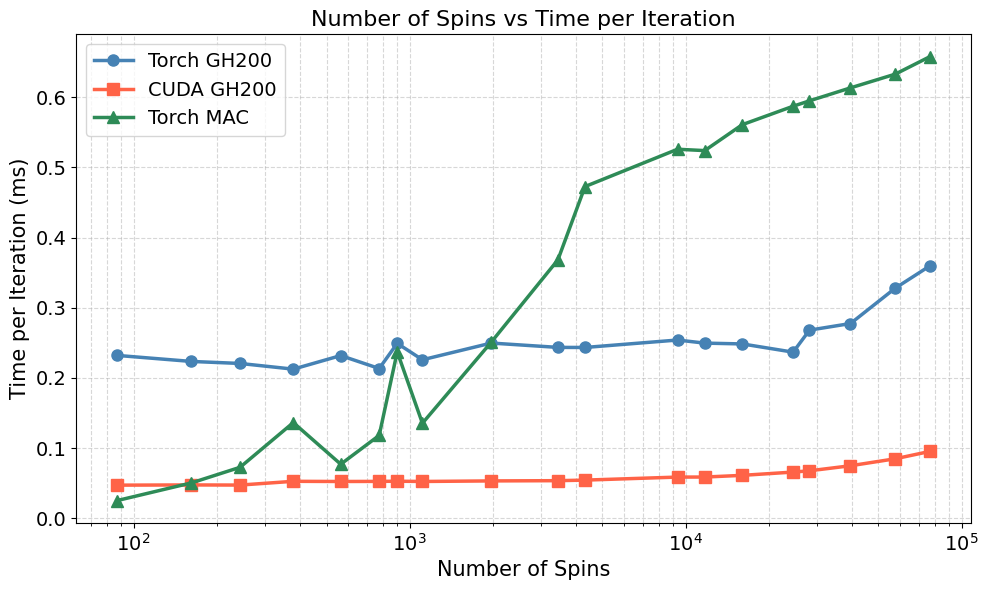

In [32]:
import matplotlib.pyplot as plt

# Data from timing_results.txt (CUDA)
cuda_num_spins = [776, 76952, 9352, 379, 1977, 4322, 57512, 87, 24536, 563,
                  16057, 39602, 902, 162, 11738, 243, 1113, 3447, 28127]
cuda_t_anneal =  [x/9.160 for x in [1.955020, 3.295915, 2.326485, 1.946633, 2.287007, 2.229457,
                  3.002958, 2.126095, 2.168310, 2.123634, 2.275610, 2.541835,
                  2.282828, 2.047055, 2.286184, 2.020918, 2.068863, 2.230506, 2.455465]]

# Data from timing_results_DA1.txt
da1_num_spins = [776, 76952, 9352, 379, 1977, 4322, 57512, 87, 24536, 563,
                 16057, 39602, 902, 162, 11738, 243, 1113, 3447, 28127]
da1_t_anneal =  [x/9.160 for x in [0.482180, 0.873800, 0.538411, 0.483236, 0.488451, 0.498898,
                 0.777191, 0.433127, 0.603762, 0.480906, 0.561006, 0.686312,
                 0.484602, 0.435917, 0.538923, 0.434248, 0.481165, 0.491640, 0.620338]]

# Data from timing_results.txt (MAC)
mac_num_spins = [776, 76952, 9352, 379, 1977, 4322, 57512, 87, 24536, 563,
                 16057, 39602, 902, 162, 11738, 243, 1113, 3447, 28127]
mac_t_anneal =  [x/9.160 for x in [1.082365, 6.025089, 4.815551, 1.249423, 2.299294, 4.328704,
                 5.795105, 0.231379, 5.376745, 0.706206, 5.136411, 5.616366,
                 2.172262, 0.462701, 4.797947, 0.666018, 1.240736, 3.372285, 5.447208]]

# Sort by num_spins for a clean line plot
cuda_sorted = sorted(zip(cuda_num_spins, cuda_t_anneal))
da1_sorted  = sorted(zip(da1_num_spins, da1_t_anneal))
mac_sorted  = sorted(zip(mac_num_spins, mac_t_anneal))

cuda_x, cuda_y = zip(*cuda_sorted)
da1_x,  da1_y  = zip(*da1_sorted)
mac_x,  mac_y  = zip(*mac_sorted)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cuda_x, cuda_y, marker='o', label='Torch GH200', color='steelblue', linewidth=2.5, markersize=8)
ax.plot(da1_x,  da1_y,  marker='s', label='CUDA GH200',  color='tomato', linewidth=2.5, markersize=8)
ax.plot(mac_x,  mac_y,  marker='^', label='Torch MAC',  color='seagreen', linewidth=2.5, markersize=8)

ax.set_xscale('log')
ax.set_xlabel('Number of Spins', fontsize=15)
ax.set_ylabel('Time per Iteration (ms)', fontsize=15)
ax.set_title('Number of Spins vs Time per Iteration', fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('spins_vs_time_per_iteration_for_mac_gh200.png', dpi=150)
plt.show()

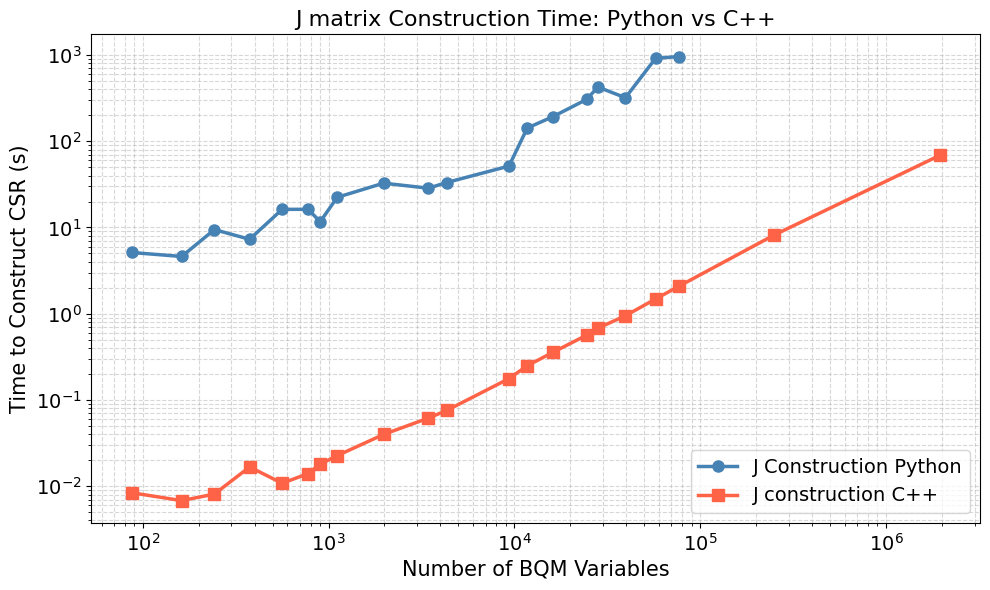

In [6]:
import matplotlib.pyplot as plt

# Data
x = [87, 162, 243, 376, 563, 776, 902, 1113, 1977, 3447, 4322,
     9352, 11738, 16057, 24536, 28127, 39602, 57512, 76952,
     248722, 1943124]

y_python = [5.13, 4.61, 9.45, 7.3, 16.24, 16.24, 11.67, 22.38, 32.66,
            28.56, 33.23, 51.53, 142.58, 192.04, 306.56, 425.72,
            319.87, 915.13, 960.66]

y_cpp = [0.0084, 0.0068, 0.0081, 0.0167, 0.0108, 0.014, 0.018, 0.0226,
         0.0398, 0.0616, 0.0755, 0.1767, 0.2493, 0.3551, 0.5656,
         0.6787, 0.9477, 1.4819, 2.0861, 8.1294, 68.459]

# Match x for Python
x_python = x[:len(y_python)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_python, y_python,
        marker='o',
        label='J Construction Python',
        color='steelblue',
        linewidth=2.5,
        markersize=8)

ax.plot(x, y_cpp,
        marker='s',
        label='J construction C++',
        color='tomato',
        linewidth=2.5,
        markersize=8)

# Log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Number of BQM Variables', fontsize=15)
ax.set_ylabel('Time to Construct CSR (s)', fontsize=15)
ax.set_title('J matrix Construction Time: Python vs C++', fontsize=16)

# Styling
ax.legend(fontsize=14, loc='lower right')
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('csr_construction_loglog.png', dpi=150)
plt.show()

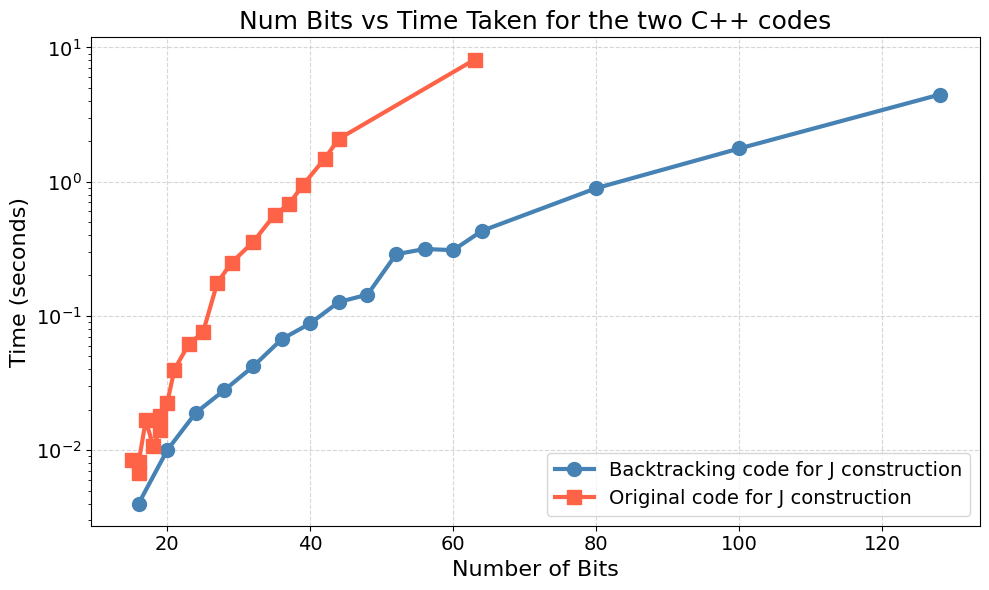

In [14]:
import matplotlib.pyplot as plt

# Dataset 1
bits1 = [16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 80, 100, 128]
time1 = [0.004, 0.01, 0.019, 0.028, 0.042, 0.067, 0.088, 0.127,
         0.144, 0.288, 0.315, 0.309, 0.43, 0.895, 1.768, 4.452]

# Dataset 2
bits2 = [15, 16, 16, 17, 18, 19, 19, 20, 21, 23, 25, 27, 29, 32, 35, 37, 39, 42, 44, 63]
time2 = [0.0084, 0.0068, 0.0081, 0.0167, 0.0108, 0.014, 0.018, 0.0226,
         0.0398, 0.0616, 0.0755, 0.1767, 0.2493, 0.3551, 0.5656, 0.6787,
         0.9477, 1.4819, 2.0861, 8.1294]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bits1, time1, marker='o', color='steelblue',
        linewidth=3, markersize=10, label='Backtracking code for J construction')

ax.plot(bits2, time2, marker='s', color='tomato',
        linewidth=3, markersize=10, label='Original code for J construction')

# Labels and title
ax.set_xlabel("Number of Bits", fontsize=16)
ax.set_ylabel("Time (seconds)", fontsize=16)
ax.set_title("Num Bits vs Time Taken for the two C++ codes", fontsize=18)

ax.set_yscale('log')

# Ticks
ax.tick_params(axis='both', labelsize=14)

# Legend
ax.legend(fontsize=14)

# Grid (optional but nice)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

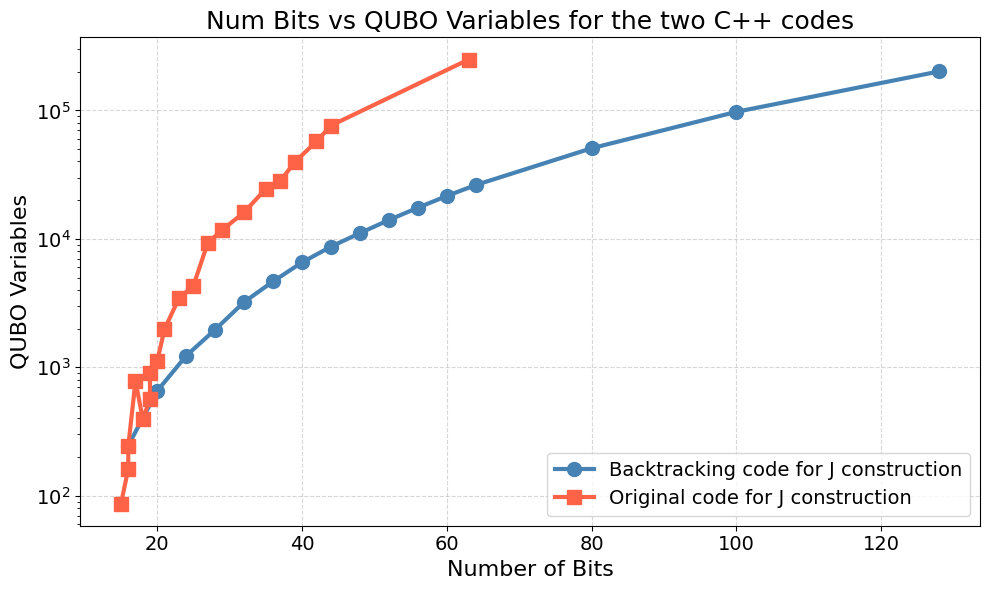

In [13]:
import matplotlib.pyplot as plt

# Dataset 1
bits1 = [16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 80, 100, 128]
qubo1 = [246, 655, 1229, 1964, 3219, 4661, 6554, 8694,
         11077, 14009, 17465, 21555, 26239, 50693, 97417, 200968]

# Dataset 2
bits2 = [15, 16, 16, 17, 18, 19, 19, 20, 21, 23, 25, 27, 29, 32, 35, 37, 39, 42, 44, 63]
qubo2 = [87, 162, 243, 781, 397, 563, 902, 1113,
         1977, 3447, 4322, 9352, 11749, 16069, 24536,
         28141, 39602, 57329, 76168, 248722]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bits1, qubo1, marker='o', color='steelblue',
        linewidth=3, markersize=10, label='Backtracking code for J construction')

ax.plot(bits2, qubo2, marker='s', color='tomato',
        linewidth=3, markersize=10, label='Original code for J construction')

# Labels and title
ax.set_xlabel("Number of Bits", fontsize=16)
ax.set_ylabel("QUBO Variables", fontsize=16)
ax.set_title("Num Bits vs QUBO Variables for the two C++ codes", fontsize=18)

ax.set_yscale('log')

# Ticks
ax.tick_params(axis='both', labelsize=14)

# Legend
ax.legend(fontsize=14)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# Load CSVs
row_ptr = np.loadtxt('bin_SI/row_ptr_159197.csv', delimiter=',', dtype=int)
col_idx = np.loadtxt('bin_SI/col_idx_159197.csv', delimiter=',', dtype=int)
values  = np.loadtxt('bin_SI/J_values_159197.csv', delimiter=',')

# Infer matrix size
n = len(row_ptr) - 1

# Build CSR matrix
J = csr_matrix((values, col_idx, row_ptr), shape=(n, n))

# Convert to dense (only if it fits in memory!)
J_dense = J.toarray()

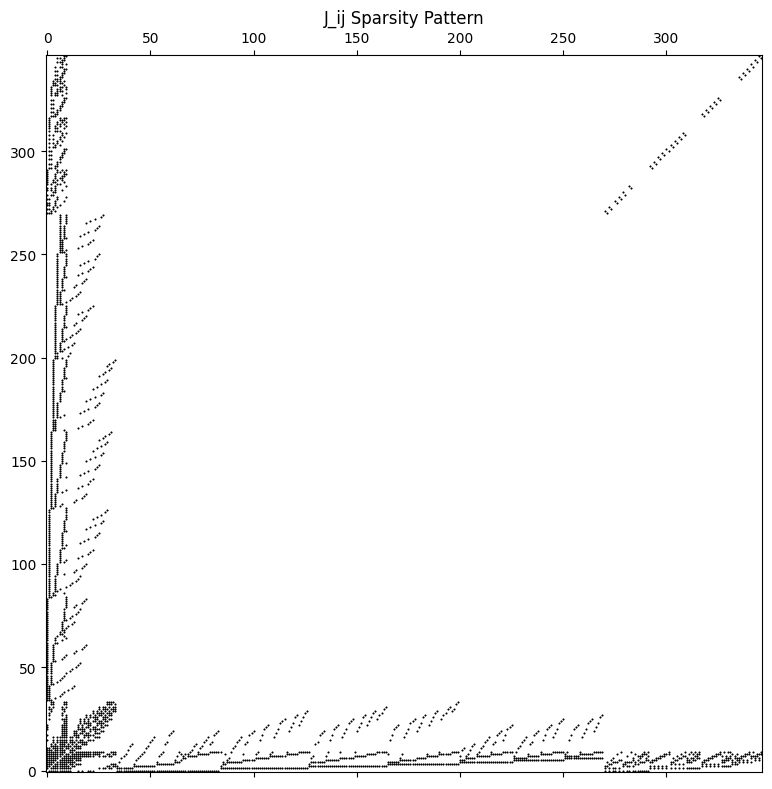

In [4]:
plt.figure(figsize=(8, 8))
plt.spy(J, markersize=0.5, color='black')
plt.gca().invert_yaxis()  # matches image orientation
plt.title('J_ij Sparsity Pattern')
plt.tight_layout()
plt.show()

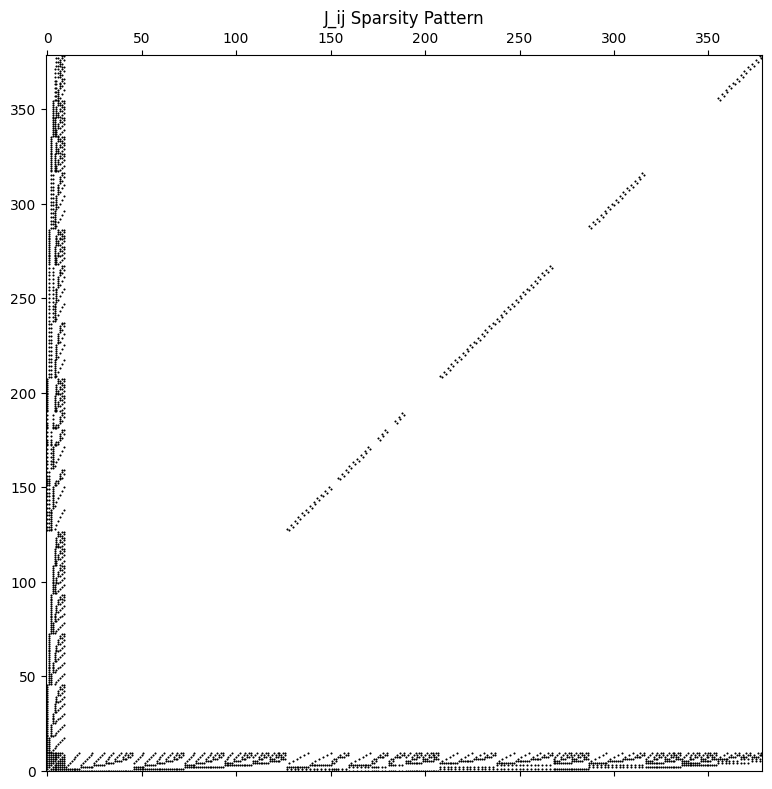

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# Load CSVs
row_ptr = np.loadtxt('bin_SI/row_ptr_159197.csv', delimiter=',', dtype=int)
col_idx = np.loadtxt('bin_SI/col_idx_159197.csv', delimiter=',', dtype=int)
values  = np.loadtxt('bin_SI/J_values_159197.csv', delimiter=',')

# Infer matrix size
n = len(row_ptr) - 1

# Build CSR matrix
J = csr_matrix((values, col_idx, row_ptr), shape=(n, n))

# Convert to dense (only if it fits in memory!)
J_dense = J.toarray()

plt.figure(figsize=(8, 8))
plt.spy(J, markersize=0.5, color='black')
plt.gca().invert_yaxis()  # matches image orientation
plt.title('J_ij Sparsity Pattern')
plt.tight_layout()
plt.show()

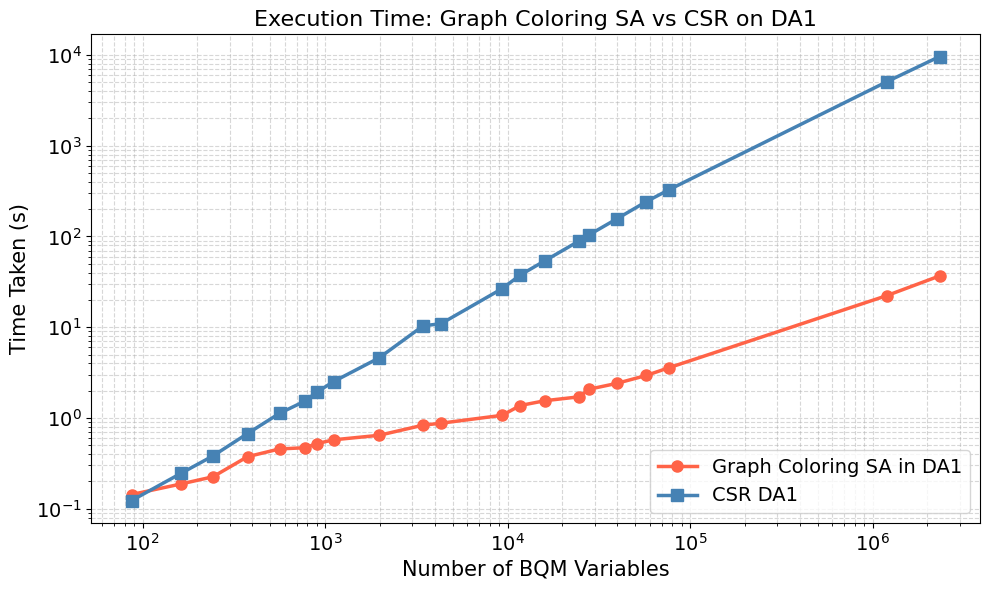

In [2]:
import matplotlib.pyplot as plt

# Data
x = [87, 162, 243, 376, 563, 776, 902, 1113, 1977, 3447, 4322,
     9352, 11738, 16057, 24536, 28127, 39602, 57512, 76952,
     1195477, 2331194]

y_graph_coloring = [0.143506, 0.187448, 0.225119, 0.374744, 0.456539,
                    0.470472, 0.522329, 0.574992, 0.645018, 0.834496,
                    0.876682, 1.071316, 1.373698, 1.552022, 1.709848,
                    2.081261, 2.405039, 2.94198, 3.590956, 22.293049,
                    36.781393]

y_csr = [0.123, 0.245, 0.382, 0.674, 1.126,
         1.536, 1.925, 2.518, 4.594, 10.362,
         10.948, 26.665, 37.604, 54.178, 88.737,
         104.881, 155.96, 241.79, 328.61, 5064.2,
         9610.69]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, y_graph_coloring,
        marker='o',
        label='Graph Coloring SA in DA1',
        color='tomato',
        linewidth=2.5,
        markersize=8)

ax.plot(x, y_csr,
        marker='s',
        label='CSR DA1',
        color='steelblue',
        linewidth=2.5,
        markersize=8)

# Log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Number of BQM Variables', fontsize=15)
ax.set_ylabel('Time Taken (s)', fontsize=15)
ax.set_title('Execution Time: Graph Coloring SA vs CSR on DA1', fontsize=16)

# Styling
ax.legend(fontsize=14, loc='lower right')
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('execution_time_loglog.png', dpi=150)
plt.show()

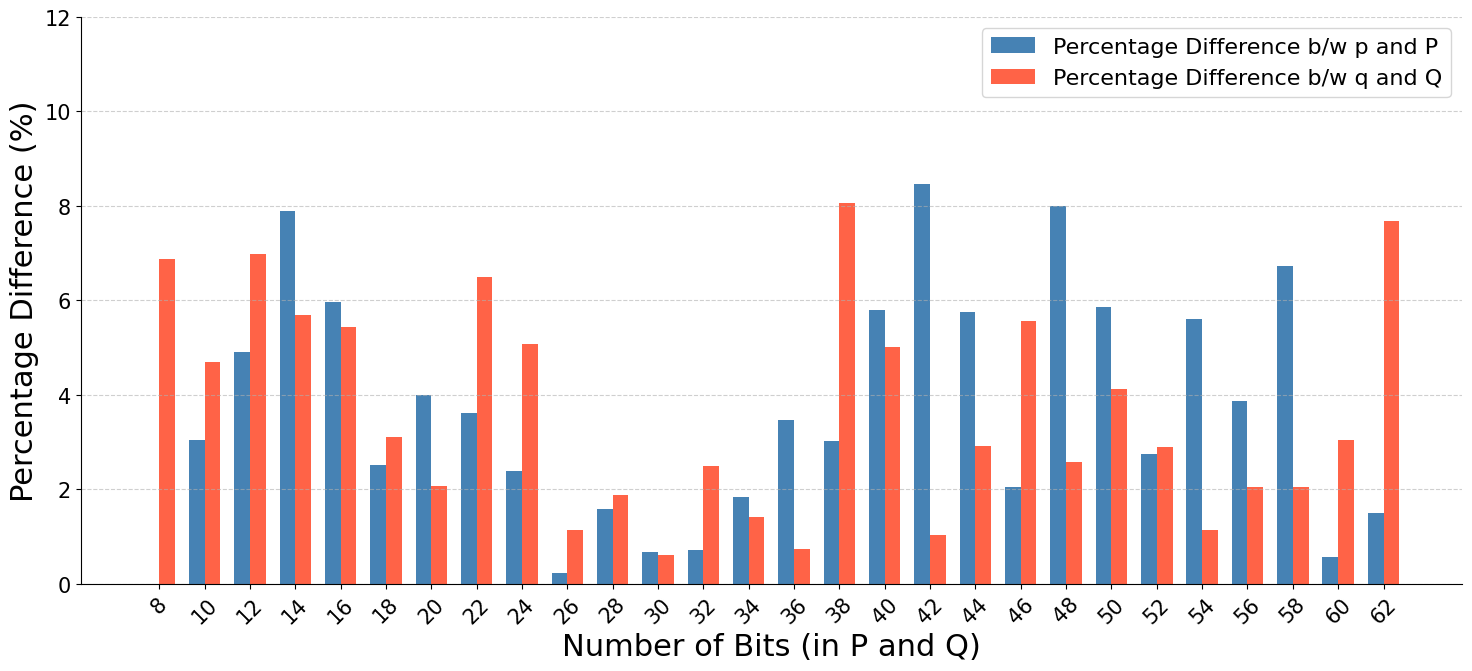

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data
bits = [
    8,10,12,14,16,18,20,22,24,26,28,30,32,34,
    36,38,40,42,44,46,48,50,52,54,56,58,60,62
]

p_diff = [
    0.00,3.05,4.91,7.90,5.97,2.51,4.00,3.62,2.38,0.22,
    1.59,0.68,0.71,1.84,3.47,3.03,5.80,8.47,5.76,2.04,
    7.99,5.86,2.75,5.60,3.87,6.73,0.56,1.50
]

q_diff = [
    6.87,4.69,6.99,5.68,5.44,3.11,2.08,6.49,5.08,1.14,
    1.88,0.61,2.49,1.41,0.74,8.06,5.02,1.04,2.92,5.56,
    2.58,4.12,2.89,1.14,2.04,2.05,3.04,7.69
]

# 🔹 Increase spacing between groups
spacing = 1.3
x = np.arange(len(bits)) * spacing
width = 0.45

plt.rcParams["font.family"] = "DejaVu Sans"

# Styling
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16
})

fig, ax = plt.subplots(figsize=(15, 7))

# Bars
ax.bar(x - width/2, p_diff, width,
       label='Percentage Difference b/w p and P',
       color='steelblue')

ax.bar(x + width/2, q_diff, width,
       label='Percentage Difference b/w q and Q',
       color='tomato')

# Labels
ax.set_xlabel("Number of Bits (in P and Q)")
ax.set_ylabel("Percentage Difference (%)")

# Ticks
ax.set_xticks(x)
ax.set_xticklabels(bits, rotation=45)

# 🔹 Set Y-axis limit to 12%
ax.set_ylim(0, 12)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend()

plt.tight_layout()
plt.savefig("percentage_difference_plot.png", dpi=300)
plt.show()